In [28]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import sympy as sp
from scipy.fft import fftn, fftfreq, fftshift
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import jv, kv

Beamline Parameters

In [29]:
#ARES parameters
beta = 0.999987
gamma = 196.69
pulseduration = 1e-15
bunchcharge = 5e-12
beamsize = 50e-6

#Charge of a single e-
e = 1.6e-19

CTR Angular Spectrum Formulation

In [30]:
def tr_spectral_angular_distribution(beta, bunchcharge, angle_range=(-0.4, 0.4), n=500, plot_title = ''):
    """
    Computes and plots the spectral-angular distribution of backward transition radiation
    using the generalized Ginzburg-Frank formula.

    Parameters:
        beta (float): Velocity ratio v/c of the electron.
        bunchcharge (float): Total bunch charge in Coulombs.
        angle_range (tuple): Tuple specifying the angular range in radians (min, max).
        n (int): Number of points in the angular grid.


    Returns:
        tuple: (theta array in radians, intensity array)
        xn: x coordinates of TR
        yn: y coordinates of TR
        zn: z coordinates of TR
    """
    # Constants
    c = 2.9988e8                 # Speed of light [m/s]
    epsilon = 8.8542e-12         # Vacuum permittivity [F/m]

    # Angle array
    th = np.linspace(angle_range[0], angle_range[1], n)

    # Generalized Ginzburg-Frank coefficient
    coeff = (e**2 * beta**2) / (np.pi**3 * c * epsilon)

    # Spectral-angular distribution
    intensity = coeff * ((np.sin(th))**2) / ((1 - (beta**2) * (np.cos(th)**2))**2)

    # Azimuthal parameter
    phi = np.linspace(0, 2*np.pi, n)

    # 2D mesh for polar to Cartesian conversion
    xn = np.outer(th, np.cos(phi))
    yn = np.outer(th, np.sin(phi))

    # Expand intensity to match mesh dimensions
    zn = np.zeros_like(xn)
    for i in range(len(th)):
        zn[i, :] = intensity[i]


    # Plot
    plt.figure()
    plt.plot(th * 180 / np.pi, intensity)
    plt.xlabel("Angle (degrees)")
    plt.ylabel(r"$\frac{d^2W}{d\omega d\Omega}$")
    plt.title(plot_title)
    plt.grid(True)
    plt.show()

    return th, intensity, xn, yn, zn

In [31]:
def plot_tr_3d_polar(xn, yn, zn, plot_title=''):
    """
    Plots the 3D polar radiation pattern of backward transition radiation
    using angular input and intensity.

    Parameters:
        th (ndarray): 1D array of polar angles (radians).
        intensity (ndarray): 1D array of corresponding intensities.
        n (int): Number of angular steps for azimuthal parameterization.
        title (str): Title for the 3D plot.
    """
    # Create figure and 3D axes
    fig = plt.figure(figsize=(15.5, 14))
    ax = fig.add_subplot(121, projection='3d')

    # Plot 3D surface
    ax.plot_surface(xn, yn, zn, cmap='viridis')

    # Labeling
    ax.set_xlabel('\n Theta (rad)')
    ax.set_ylabel('\n Phi (rad)')
    ax.set_zlabel('\n\nAngular \n Spectral \n Density')
    ax.set_title(plot_title)

    plt.show()  

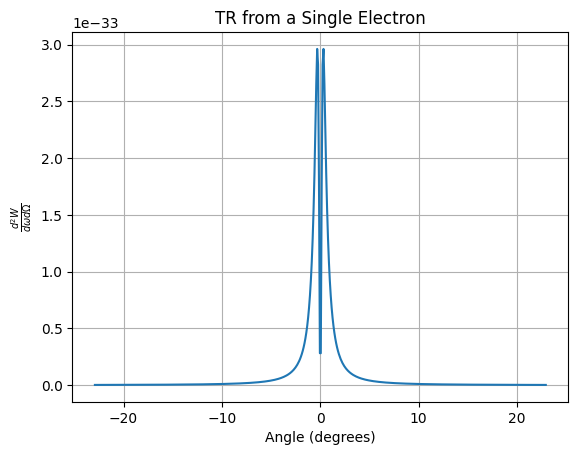

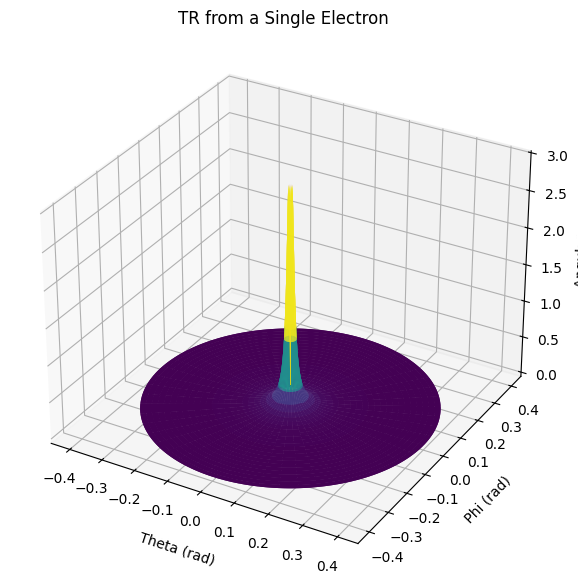

In [32]:
#example usage
th, intensity, xn, yn, zn = tr_spectral_angular_distribution(beta=beta, bunchcharge=bunchcharge, plot_title = "TR from a Single Electron")
plot_tr_3d_polar(xn, yn, zn, plot_title="TR from a Single Electron")

TR Spectrum Visulization

In [33]:
def plot_tr_contour(xn, yn, zn, xlim=(-0.1, 0.1), ylim=(-0.1, 0.1), plot_title = ''):
    """
    Plots a contour map of the BTR angular spectrum on a polar coordinate plane.

    Parameters:
        xn, yn: 2D arrays of Cartesian coordinates mapped from polar angles.
        zn: 2D array of intensities.
        xlim, ylim: Tuples to control the axis limits.
    """
    plt.figure()
    cp = plt.contour(xn, yn, zn, colors='black')
    plt.xlabel("Horizontal angle (rad)")
    plt.ylabel("Vertical angle (rad)")
    plt.gca().set_aspect('equal')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title(plot_title)
    plt.grid(True)
    plt.show()

In [34]:
def plot_tr_heatmap(xn, yn, zn, cmap='viridis', plot_title=''):
    """
    Plots a 2D heatmap of TR radiation using imshow.

    Parameters:
        xn, yn: 2D arrays of Cartesian coordinates mapped from polar angles.
        zn: 2D array of intensities.
        cmap: Matplotlib colormap.
    """
    plt.figure()
    im = plt.imshow(zn.T, 
                    vmin=zn.min(), vmax=zn.max(),
                    extent=[xn.min(), xn.max(), yn.min(), yn.max()],
                    origin="upper", cmap=cmap, aspect="auto")
    cb = plt.colorbar(im)
    plt.title(plot_title)
    plt.xlabel('Theta (rad)')
    plt.ylabel('Phi (rad)')
    cb.set_label('Radiation\n$J/Hz\\cdot Sr$')
    plt.grid(False)
    plt.show()

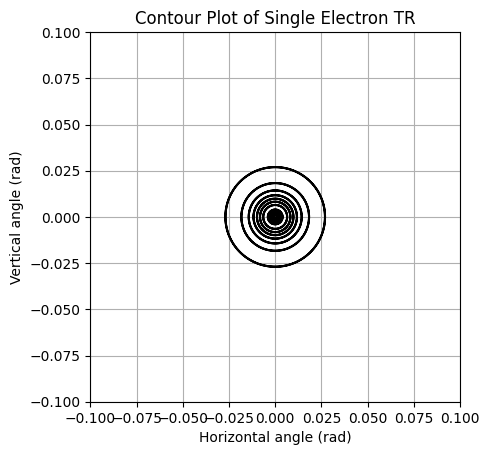

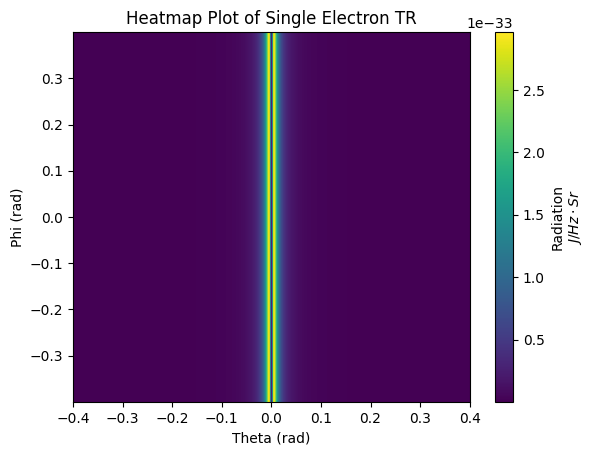

In [35]:
#example usage
plot_tr_contour(xn,yn,zn, plot_title="Contour Plot of Single Electron TR")
plot_tr_heatmap(xn,yn,zn, plot_title="Heatmap Plot of Single Electron TR")

Electron Beam Construction

In [ ]:
def compute_and_plot_electron_beam(pulseduration, beta, beamsize, n=500, 
                                    xlim=(-1e7, 1e7), plot_slice_axis=2):
    """
    Computes a 3D Gaussian electron bunch and its 3D Fourier transform,
    and visualizes both spatial and frequency-domain central slices.

    Parameters:
        pulseduration (float): Pulse duration [s].
        beta (float): Electron speed as fraction of c.
        beamsize (float): Transverse beam size (sigma_t) [m].
        n (int): Number of grid points per axis.
        xlim (tuple): Range of spatial domain in meters.
        plot_slice_axis (int): Slice axis (0=x, 1=y, 2=z) for spatial plot.

    Returns:
        dict: {
            "density": 3D spatial distribution,
            "transform": 3D Fourier transform,
            "f2": Normalized and reshaped Fourier transform 
            "kx", "ky", "kz": 1D frequency axes
        }
    """
    # Constants
    c = 2.9988e8
    v = beta * c

    # Electron beam dimensions
    sigmaz = pulseduration * v  #longitudinal length
    sigmat = beamsize           #transverse length

    # 1D spatial grid
    x1 = np.linspace(xlim[0], xlim[1], n)
    y1 = np.linspace(xlim[0], xlim[1], n)
    z1 = np.linspace(xlim[0], xlim[1], n)

    dx = x1[1] - x1[0]
    dy = y1[1] - y1[0]
    dz = z1[1] - z1[0]

    # 3D Gaussian beam profile
    Xsq = x1[:, None, None]**2
    Ysq = y1[None, :, None]**2
    Zsq = z1[None, None, :]**2

    coeff_t = 1/2*np.pi*sigmat**2
    coeff_z = 1/(np.sqrt(2*np.pi)*sigmaz)
    density = coeff_t*(np.exp(-(Xsq + Ysq)/2*sigmat**2))*coeff_z*(np.exp(-(Zsq)/2*sigmaz**2))

    # Fourier Transform
    transform = fftn(density)
    transform = fftshift(transform)

    kx = fftshift(fftfreq(n, d=dx))
    ky = fftshift(fftfreq(n, d=dy))
    kz = fftshift(fftfreq(n, d=dz))

    # Spatial Domain Slice in middle of distribution hence n//2
    plt.figure()
    if plot_slice_axis == 0:
        plt.imshow(density[n//2, :, :], extent=(y1[0], y1[-1], z1[0], z1[-1]), cmap='viridis')
        plt.xlabel("y (m)")
        plt.ylabel("z (m)")
    elif plot_slice_axis == 1:
        plt.imshow(density[:, n//2, :], extent=(x1[0], x1[-1], z1[0], z1[-1]), cmap='viridis')
        plt.xlabel("x (m)")
        plt.ylabel("z (m)")
    else:
        plt.imshow(density[:, :, n//2], extent=(x1[0], x1[-1], y1[0], y1[-1]), cmap='viridis')
        plt.xlabel("x (m)")
        plt.ylabel("y (m)")

    plt.colorbar(label='J/Hz·Sr')
    plt.title("Electron Beam - Spatial Gaussian Distribution")
    plt.tight_layout()
    plt.show()

    # Fourier Domain Slice
    coeff = 1 / ((2 * np.pi)**3)
    f2 = coeff * (np.abs(transform[:, :, n//2])**2)

    plt.figure()
    plt.imshow(f2, extent=(kx[0], kx[-1], ky[0], ky[-1]), cmap='viridis')
    plt.colorbar(label='J/Hz·Sr')
    plt.xlabel("kx (1/m)")
    plt.ylabel("ky (1/m)")
    plt.title("2D Slice of 3D Fourier Transform - Gaussian Distribution")
    plt.tight_layout()
    plt.show()

    return {
        "density": density,
        "transform": transform,
        "f2": f2,
        "kx": kx,
        "ky": ky,
        "kz": kz
    }

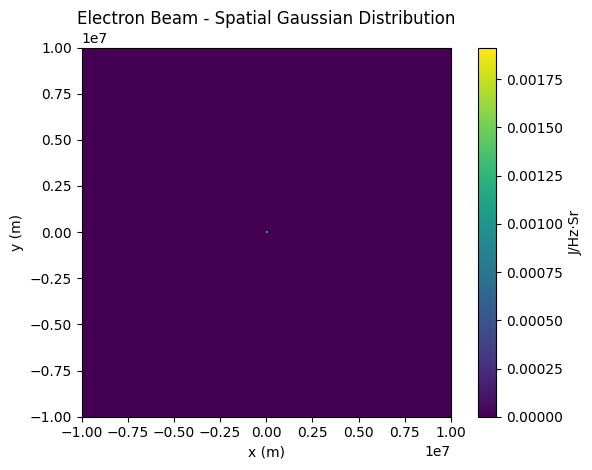

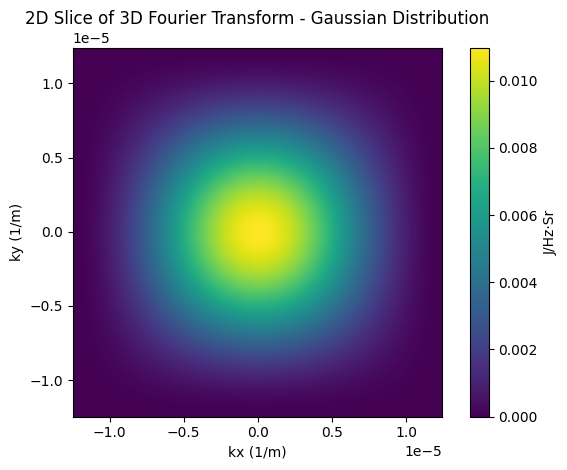

In [37]:
result = compute_and_plot_electron_beam(
    pulseduration=pulseduration,
    beta=beta,
    beamsize=beamsize,
    n=500)

Calculation of Multi Electron Radiation

In [38]:
def multi_electron_radiation(W1, Ne, formfactor):
    """
    Returns the transition radiation angular spectral distribution for Ne number of electrons with absolute value squared form factor f2 = |f|^2
    and single electron angular spectral distribution W1 (Gaussian electron bunch distribution)
    

    W1 is radiation of a single electron
    """
    Wn = W1 * (Ne + Ne*(Ne-1))*f2
    return Wn

Calculating Form Factor (f2), Number of electrons (e), and Radiation from Bunch (Wn)

In [39]:
f2 = result['f2']
N = bunchcharge/e
Wn = multi_electron_radiation(zn, N, f2)

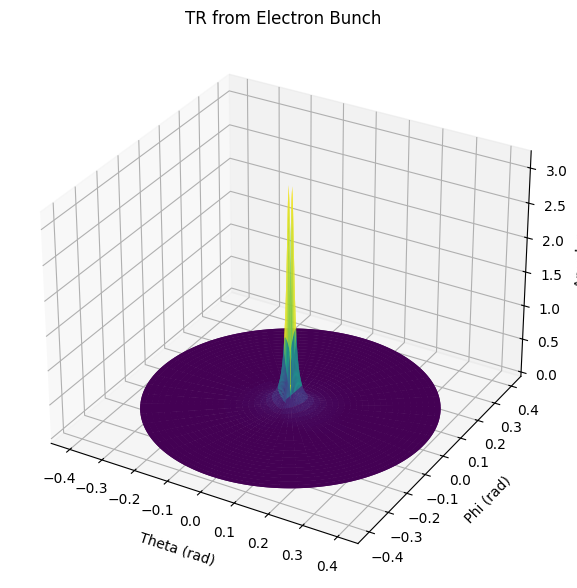

In [40]:
plot_tr_3d_polar(xn, yn, Wn, plot_title="TR from Electron Bunch")

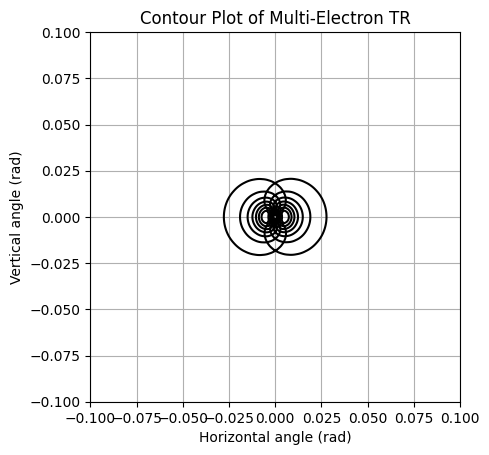

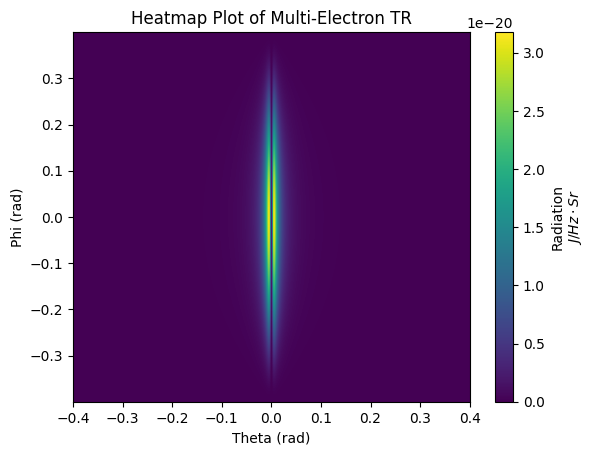

In [41]:
plot_tr_contour(xn,yn,Wn, plot_title="Contour Plot of Multi-Electron TR")
plot_tr_heatmap(xn,yn,Wn, plot_title="Heatmap Plot of Multi-Electron TR")

In [ ]:
#Form Factor Code
electron_velocity = 0.998 * 3 * 10**8
sigma_z = pulseduration * electron_velocity #changing blob of electrons
sigma_r = beamsize #the transverse beam size should just be the beam size
#sigma r is the transverse electron bunch size
#sigma z is the longitudinal electron bunch size
k1 = (2*np.pi)/lambda_1
k2 = (2*np.pi)/lambda_2
def sqrt_F_k(k1, k2, sigma_r, sigma_z, theta, phi):
    b11 = 5 #simplified to 5
    half_fact = np.sqrt(np.pi) / 2  #(1/2)!
    term1 = 0.5 * b11 * half_fact * ( ((k1 + k2) * sigma_r * np.sin(theta)) / np.sqrt(2) )**1
    term2_no_exponent = -0.5 * sigma_z**2 * ((k1 - k2 - (k1 + k2) * np.cos(theta))**2)
    term2 = np.exp(term2_no_exponent)
    term3_no_exponent = -0.5 * sigma_r**2 * ((k1 + k2) * np.sin(theta))**2 + 1j * (phi - np.pi / 2)
    term3 = np.exp(term3_no_exponent)
    sqrt_Fk = term1 * term2 * term3
    print(sqrt_Fk)
    return sqrt_Fk




In [ ]:
import numpy as np
from math import factorial
'''
b_ls should be a dictionary as follows: 
it is a coefficient that depends on both s and l 
these coeffs need to be stored for each s and l 
the paper should define b_ls
the paper defines a formula actually to compute b_ls so we 
can code thsi
b_ls = {
    (1, 0): 1.0,
    (1, 2): 0.3,
    (1, -2): 0.3,
    (2, 0): 0.05,
    (2, 2): 0.1,
    (2, -2): 0.1,
}
'''


def compute_b_ls(s_max, l_max):
    
    pass
  
def F_k(k, kb, sigma_r, sigma_z, theta, phi, b_ls, 
        s_max=10, l_max=10):

    total = 0.0 + 0.0j
    for s in range(1, s_max + 1):
        for l in range(-l_max, l_max ):
            
            #get coefficient b_ls
            b = b_ls.get((s, l), 0.0)
            
            #factorial term
            # i think for odd l b_ls should be 0? 
            # l is the OAM index and if it is odd the 
            # integrals over azimuthal angle give zero
            denom = factorial(abs(l) // 2) 
         
            # polynomial term
            poly = (k * sigma_r * np.sin(theta) / np.sqrt(2))**abs(l)
            
            # exponential term
            # kb is the wavenumber of the microbunching and comes from seed
            #laser wavelength lambda_b
            #kb = 2pi / lambda_b
            expo = np.exp(
                -0.5 * sigma_z**2 * (kb - k*np.cos(theta))**2
                -0.5 * sigma_r**2 * (k*np.sin(theta))**2
                + 1j * l * (phi - np.pi/2)
            )
            
            total += b * (1/denom) * poly * expo

    return 0.5 * total


In [ ]:

import numpy as np
from scipy.special import airy
def airy_beam(x, z, wavelength, pulse_duration, transverse_size, alpha=0.1, gamma=1.0):
    k = 2 * np.pi / wavelength
    # Meshgrid for evaluation
    X, Z = np.meshgrid(x, z, indexing='ij')
    #this is the argument we will pass into the airy function!
    airy_arg = gamma * X + ((gamma**4 * Z**2) / (4 * k**2)) + 1j * alpha * gamma * Z / k
    #airy function
    Ai, _, _, _ = airy(airy_arg)
    phi = (gamma**2 * Z / (2 * k)) * (gamma * X - ((gamma**4 * Z**2) / (6 * k**2)) + ((alpha**2) / (gamma**2)) )     #φ(x,z)
    psi = Ai * np.exp(1j * phi + alpha * (X - (gamma**3 * Z**2) / (2 * k**2)))
    return psi, X, Z